## <h1><center>Course: Introduction to Machine Learning</center></h1>
## <h1><center>Assignment 5</center></h1>
### <h1><center>Important NOTE: In order to get full credit, for every question, you need to provide the details of your work on how to get to a solution or the end of a proof.</center></h1>
#### <h1><center>Instructor: Tan Bui-Thanh</center></h1>
#### <h1><center>TA: Venugopal Ranganathan</center></h1>
##### <h1><center>Due date: 11:59 pm, 31 October, Friday </center></h1>
#### <h1><center>All submission MUST be in pdf format, except codes. All code outputs should be reported in pdf format.</center></h1>

## Q1 (10 Points) Neural Network: Back-Propagation and Gradient Vanishing

In lecture 13, the neural network $\Psi: \boldsymbol{x} \in \mathbb{R}^2 \mapsto y_\text{label} \in \mathbb{R}$ and its back-propagation update for one training sample are given. The neural network includes one input layer of 2 neurons (the dimension of the input $\boldsymbol{x}$), one hidden layer of 3 neurons, one output layer of 1 neuron (the dimension of the output $y_\text{label}$). Note: we use the sigmoid activation function for each neuron in the hidden layer(s).

**Question:**

 Given the code, we let the input be $\boldsymbol{x} \in \mathbb{R}^4$, $\boldsymbol{x} = [1, -.5, 2, -1]$, and the output be $y_\text{label} = 1$.

1. You need to:
- Build a neural network with 5 hidden layers, each layer having 3 neurons.
- Train the network using back-propagation until the value of loss function stops decreasing significantly. You must choose the tolerance for halting training.
- Plot the norm of gradient with respect to the weights of each hidden layer versus the number of training iterations. In particular, let $L$ be the loss function and the $\boldsymbol{\theta}^i$ be the vector of all weights from the $i$-th hidden layer. The norm that you are looking for is the L2-norm of the vector ${\frac{\partial L}{\partial \boldsymbol{\theta}^i}}$. You need to plot 6 curves corresponding to 6 sets of weights: weights of 5 hidden layers and weights of the output layer. Discuss your observations.
2. The architecture from part one of the question is simply a fully connected neural network .i.e,
    $$\boldsymbol{h}_{i+1} = \text{self.l1.forward}(\boldsymbol{h}_i), \quad i = 0,..., n, \text{ and } \boldsymbol{h}_0 = \boldsymbol{x}$$
    
    where $\boldsymbol{h}_i$ is the activation value in the network at the $i$-th hidden layer.
    In general, it encounters the vanishing gradient issue if the number of layers is large. The Residual Network ([ResNet](https://arxiv.org/abs/1512.03385), one of most cited works in machine learning)  architecture is proposed to deal with this issue and it is given as

    $$\boldsymbol{h}_{i+1} = \boldsymbol{h}_i + \text{self.l1.forward}(\boldsymbol{h}_i), \quad i = 0,..., n, \text{ and } \boldsymbol{h}_0 = \boldsymbol{x}.$$
    
You need to:
- Derive the back-propagation update for the ResNet architecture with the Sigmoid activation function.
- Modify the code to compute the gradient using your derived back-propagation for ResNet.
- Train a ResNet with 5 hidden layers of 3 neurons.
- Plot the norm of gradient with respect to the weights of each hidden layer versus the number of training iterations. In particular, let $L$ be the loss function and the $\boldsymbol{\theta}^i$ be the vector of all weights from the $i$-th hidden layer. The norm that you are looking for is the L2-norm of the vector ${\frac{\partial L}{\partial \boldsymbol{\theta}^i}}$. You need to plot 6 curves corresponding to 6 sets of weights: weights of 5 hidden layers and weights of the output layer. Discuss what you observe.
3.  Compare and discuss the results of part 1 and part 2.

/var/folders/wr/3xnjd2456475rtwd7xnvg99h0000gn/T/ipykernel_66311/537710324.py:63: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  return float(J)
/var/folders/wr/3xnjd2456475rtwd7xnvg99h0000gn/T/ipykernel_66311/537710324.py:98: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  return float(J)


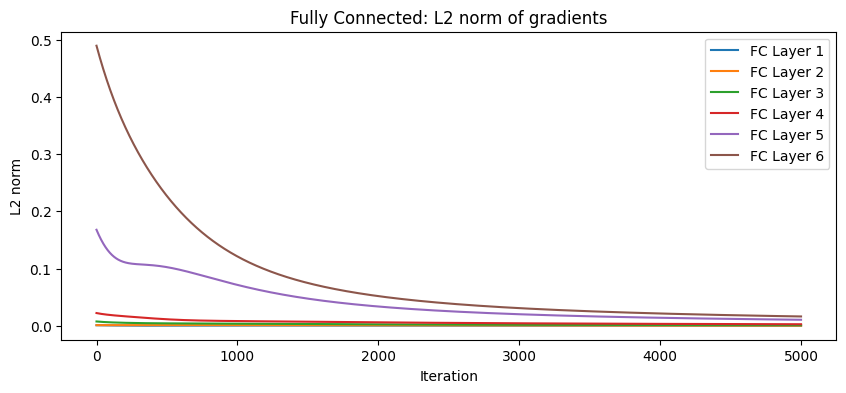

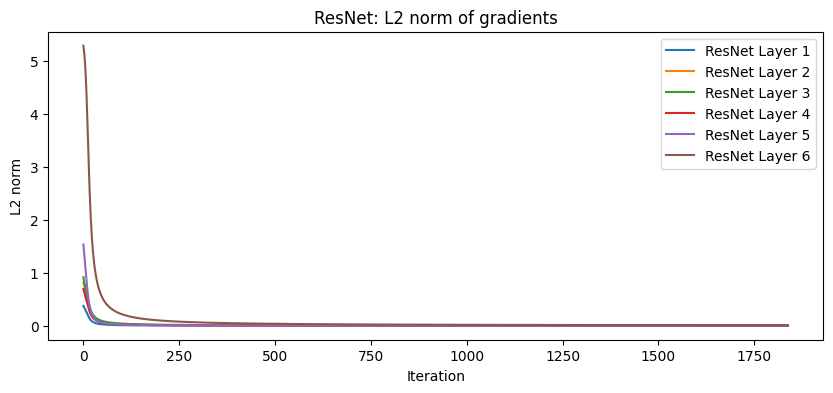

FC iters: 5000 final loss: 0.014616606378141836
ResNet iters: 1839 final loss: 0.0017534178308144892


In [1]:
import numpy as np
import matplotlib.pyplot as plt

# a single linear layer with sigmoid activation
class LinearSigmoidLayer():
    def __init__(self, in_dim, out_dim):
        self.W = np.random.normal(size=(in_dim,out_dim))
        self.W_grad = np.zeros_like(self.W)

        self.afunc = lambda x: 1. / (1. + np.exp(-x))

    # forward function to get output
    def forward(self, x):
        Wx = np.matmul(x, self.W)
        self.y = self.afunc(Wx)
        self.x = x
        return self.y

    # backward function to compute gradients
    def backward(self, grad_out):
        self.W_grad = np.matmul(
            self.x.transpose(),
            self.y * (1-self.y) * grad_out,
            )
        grad_in = np.matmul(
            self.y * (1-self.y) * grad_out,
            self.W.transpose()
            )

        return grad_in

# a multi-layer fully connected network
class Net():
    def __init__(self, x_dim, h_dim, num_hidden=5):
        # create 5 hidden layers
        self.layers = [LinearSigmoidLayer(x_dim, h_dim)]
        for _ in range(num_hidden-1):
            self.layers.append(LinearSigmoidLayer(h_dim, h_dim))
        self.out_layer = LinearSigmoidLayer(h_dim, 1)

    # get output
    def predict(self, x):
        h = x
        for layer in self.layers:
            h = layer.forward(h)
        self.y = self.out_layer.forward(h)
        return self.y

    # backprop
    def backward(self, label):
        eps = 1e-12
        # binary cross entropy loss, and gradients
        if label == 1:
            J = -np.log(self.y + eps)
            dJ = -1/self.y
        else:
            J = -np.log(1 - self.y + eps)
            dJ = 1/(1-self.y)

        grad = self.out_layer.backward(dJ)
        for layer in reversed(self.layers):
            grad = layer.backward(grad)
        return float(J)

    # update weights according to gradients
    def grad_step(self, lr=1e-4):
        for layer in self.layers:
            layer.W -= lr*layer.W_grad
        self.out_layer.W -= lr*self.out_layer.W_grad

class ResNet(Net):
    def __init__(self, x_dim, h_dim, num_hidden=5):
        self.pre = LinearSigmoidLayer(x_dim, h_dim)
        self.layers = [LinearSigmoidLayer(h_dim, h_dim) for _ in range(num_hidden)]
        self.out_layer = LinearSigmoidLayer(h_dim, 1)

    def predict(self, x):
        h = self.pre.forward(x)
        for layer in self.layers:
            h = h + layer.forward(h)
        self.y = self.out_layer.forward(h)
        return self.y

    def backward(self, label):
        eps = 1e-12
        if label == 1:
            J = -np.log(self.y + eps)
            dJ = -1/self.y
        else:
            J = -np.log(1 - self.y + eps)
            dJ = 1/(1-self.y)

        grad = self.out_layer.backward(dJ)
        for layer in reversed(self.layers):
            grad_nonlin = layer.backward(grad)
            grad = grad + grad_nonlin
        grad = self.pre.backward(grad)
        return float(J)

x = np.array([[1.0, -0.5, 2.0, -1.0]])
y_label = 1

# Fully Connected Network
net_fc = Net(x_dim=4, h_dim=3)
losses_fc = []
grad_norms_fc = [[] for _ in range(6)]

tol = 1e-6
prev_loss = 1e9
for i in range(5000):
    out = net_fc.predict(x)
    J = net_fc.backward(y_label)
    net_fc.grad_step(lr=1e-2)
    losses_fc.append(J)
    for j, layer in enumerate(net_fc.layers):
        grad_norms_fc[j].append(np.linalg.norm(layer.W_grad))
    grad_norms_fc[-1].append(np.linalg.norm(net_fc.out_layer.W_grad))
    if abs(prev_loss - J) < tol:
        break
    prev_loss = J

# Residual Network
net_res = ResNet(x_dim=4, h_dim=3)
losses_res = []
grad_norms_res = [[] for _ in range(6)]

prev_loss = 1e9
for i in range(5000):
    out = net_res.predict(x)
    J = net_res.backward(y_label)
    net_res.grad_step(lr=1e-2)
    losses_res.append(J)
    for j, layer in enumerate(net_res.layers):
        grad_norms_res[j].append(np.linalg.norm(layer.W_grad))
    grad_norms_res[-1].append(np.linalg.norm(net_res.out_layer.W_grad))
    if abs(prev_loss - J) < tol:
        break
    prev_loss = J

plt.figure(figsize=(10,4))
for i in range(6):
    plt.plot(grad_norms_fc[i], label=f'FC Layer {i+1}')
plt.title("Fully Connected: L2 norm of gradients")
plt.xlabel("Iteration")
plt.ylabel("L2 norm")
plt.legend()
plt.show()

plt.figure(figsize=(10,4))
for i in range(6):
    plt.plot(grad_norms_res[i], label=f'ResNet Layer {i+1}')
plt.title("ResNet: L2 norm of gradients")
plt.xlabel("Iteration")
plt.ylabel("L2 norm")
plt.legend()
plt.show()

print("FC iters:", len(losses_fc), "final loss:", losses_fc[-1])
print("ResNet iters:", len(losses_res), "final loss:", losses_res[-1])


1. The earlier layers (closer to input) have small gradients which are decreasing rapidly. The later layers (closer to output) maintain relatively larger gradients. This is the vanishing gradient problem: gradients diminising as they backpropagate through many sigmoid layers.

2. When replacing with a Residual Network, the gradients in earlier layers are larger and more stable. Gradient norms do not vanish as quickly. You can see the loss converges faster and more smoothly.

3. The identity skip in ResNet allows gradients to propagate even through many layers. This avoids the vanishing gradient problem seen in standard sigmoid-based deep nets. In practice, ResNets enable much deeper architectures to train effectively.

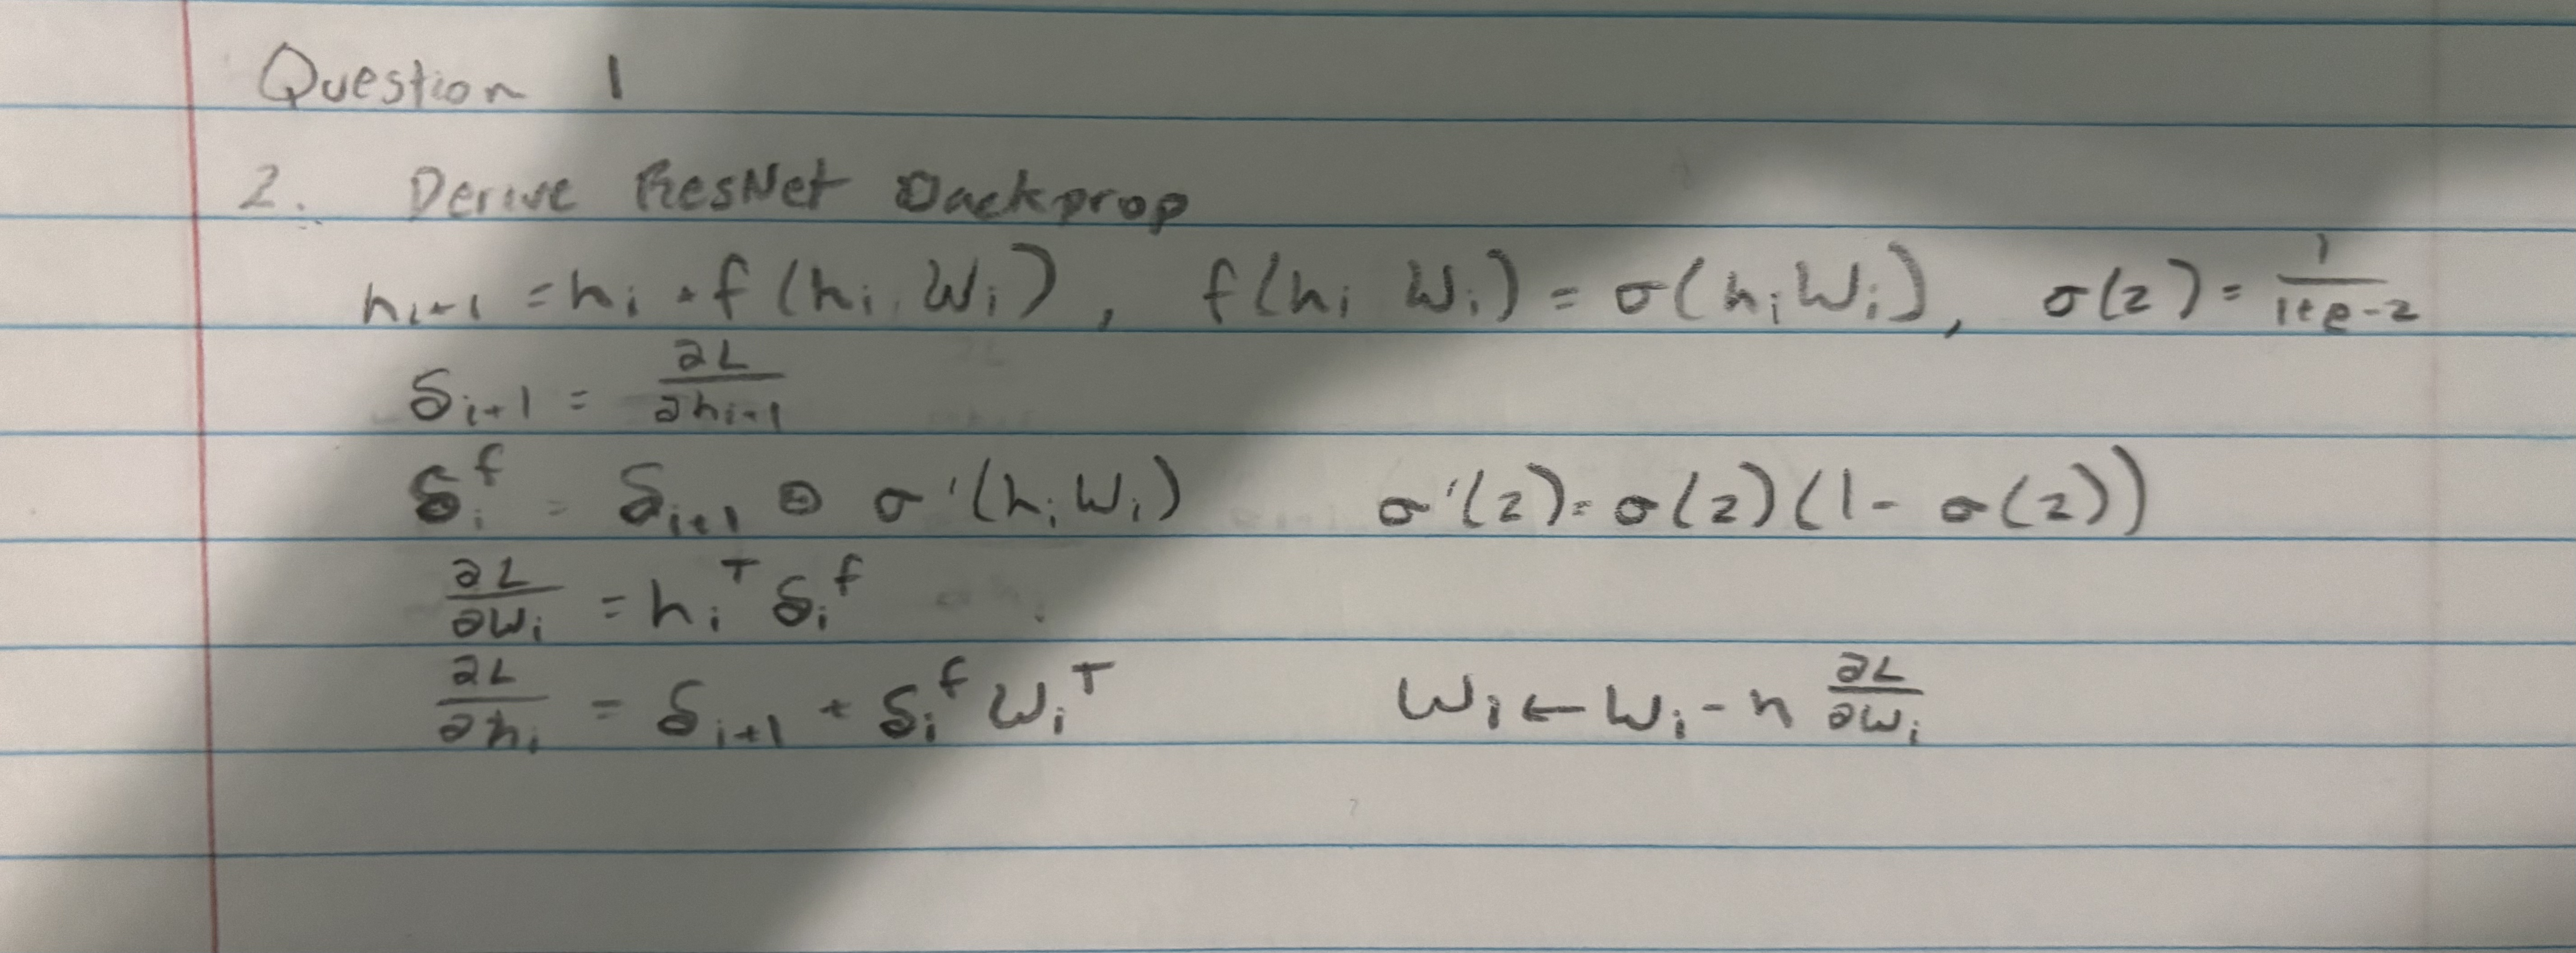

## Q2 (10 Points) MNIST Classification with Fully Connected Network

In this problem, you will investigate the effects of different hyperparameters on training a fully connected network. You will run several training settings for the MNIST dataset. From the given code, you need to plot the training and test accuracy curves for different training settings (a set of learning rate, batch size, layers, neurons, activation function):

Assume the baseline settings are: Adam Optimizer with learning rate $10^{-3}$, batch size $128$, a fully connected network of 3 hidden layers, each hidden layer having 512 neurons, and the ReLU activation function.

Experiment with hyperparameters by changing one component at a time, while keeping the others at baseline settings. Test the following hyperparameters:
- learning rate $10^{-4}$
- batch size $512$
- number of hidden layers $5$
- number of neurons $128$
- Sigmoid activation function

Train and compare accuracy plots for each hyperparameter variation, keeping other parameters fixed.

**NOTE:**
1. If training is too slow, you can run 20 epochs or fewer.
2. I recommend running the code on Google Colab (Runtype: GPU) since training the neural network is faster with GPU and you do not need to install related packages (JAX, torchvision).


In [ ]:
import time
import jax
import jax.numpy as jnp
from jax import grad, jit, vmap, random, value_and_grad
from jax.example_libraries import optimizers
from tensorflow.keras.datasets import mnist
from matplotlib import pyplot as plt
from functools import partial

# -------------------------------
# 1. Load and preprocess MNIST
# -------------------------------
(x_train, y_train), (x_test, y_test) = mnist.load_data()
x_train = x_train.reshape(-1, 28*28) / 255.0
x_test  = x_test.reshape(-1, 28*28) / 255.0

# smaller subset for faster training
x_train, y_train = x_train[:20000], y_train[:20000]
x_test, y_test   = x_test[:5000], y_test[:5000]

num_classes = 10
def one_hot(y, k=num_classes): return jnp.eye(k)[y]

x_train, y_train = jnp.array(x_train), jnp.array(y_train)
x_test, y_test = jnp.array(x_test), jnp.array(y_test)

# -------------------------------
# 2. Activation functions
# -------------------------------
def relu(x): return jnp.maximum(0, x)
def sigmoid(x): return 1 / (1 + jnp.exp(-x))

# -------------------------------
# 3. Initialize network layers
# -------------------------------
def init_layer(key, in_dim, out_dim, scale=0.01):
    w_key, b_key = random.split(key)
    return scale * random.normal(w_key, (out_dim, in_dim)), jnp.zeros((out_dim,))

def init_mlp(layer_sizes, key):
    keys = random.split(key, len(layer_sizes))
    return [init_layer(k, m, n) for k, (m, n) in zip(keys, zip(layer_sizes[:-1], layer_sizes[1:]))]

def forward(params, x, activation_fn=relu):
    for (w, b) in params[:-1]:
        x = activation_fn(jnp.dot(x, w.T) + b)
    w, b = params[-1]
    return jnp.dot(x, w.T) + b

def accuracy(params, x, y, activation_fn):
    preds = jnp.argmax(forward(params, x, activation_fn), axis=1)
    return jnp.mean(preds == y)

@partial(jit, static_argnums=(3,))
def loss(params, x, y, activation_fn):
    logits = forward(params, x, activation_fn)
    y_onehot = one_hot(y)
    log_probs = logits - jax.scipy.special.logsumexp(logits, axis=1, keepdims=True)
    return -jnp.mean(jnp.sum(y_onehot * log_probs, axis=1))

# -------------------------------
# 4. Training loop
# -------------------------------
def train_mnist(num_epochs, batch_size, lr,
                hidden_layers, hidden_size, activation_fn):
    key = random.PRNGKey(0)
    layer_sizes = [784] + [hidden_size]*hidden_layers + [10]
    params = init_mlp(layer_sizes, key)

    # Initialize optimizer
    opt_init, opt_update, get_params = optimizers.adam(lr)
    opt_state = opt_init(params)

    # Update function uses local optimizer functions
    @partial(jit, static_argnums=(4,))
    def update(params, opt_state, x, y, activation_fn):
        value, grads = value_and_grad(loss)(params, x, y, activation_fn)
        opt_state = opt_update(0, grads, opt_state)
        return get_params(opt_state), opt_state, value

    n_batches = x_train.shape[0] // batch_size
    train_accs, test_accs = [], []

    for epoch in range(num_epochs):
        perm = random.permutation(key, x_train.shape[0])
        key = random.split(key, 1)[0]
        x_train_shuffled, y_train_shuffled = x_train[perm], y_train[perm]

        for i in range(n_batches):
            xb = x_train_shuffled[i*batch_size:(i+1)*batch_size]
            yb = y_train_shuffled[i*batch_size:(i+1)*batch_size]
            params, opt_state, _ = update(get_params(opt_state), opt_state, xb, yb, activation_fn)

        train_acc = accuracy(get_params(opt_state), x_train, y_train, activation_fn)
        test_acc  = accuracy(get_params(opt_state), x_test, y_test, activation_fn)
        train_accs.append(train_acc)
        test_accs.append(test_acc)
        print(f"Epoch {epoch+1}: Train Acc={train_acc:.3f}, Test Acc={test_acc:.3f}")

    return train_accs, test_accs

# -------------------------------
# 5. Define experiments
# -------------------------------
baseline_params = {
    'num_epochs': 20,
    'batch_size': 128,
    'lr': 1e-3,
    'hidden_layers': 3,
    'hidden_size': 512,
    'activation_fn': relu
}

experiments = {
    'Baseline': baseline_params,
    'Learning Rate 1e-4': {**baseline_params, 'lr': 1e-4},
    'Batch Size 512': {**baseline_params, 'batch_size': 512},
    'Hidden Layers 5': {**baseline_params, 'hidden_layers': 5},
    'Neurons 128': {**baseline_params, 'hidden_size': 128},
    'Sigmoid Activation': {**baseline_params, 'activation_fn': sigmoid}
}

# -------------------------------
# 6. Run experiments
# -------------------------------
results = {}
for name, params in experiments.items():
    print(f"\n=== Training {name} ===")
    train_accs, test_accs = train_mnist(**params)
    results[name] = {'train': train_accs, 'test': test_accs}

# -------------------------------
# 7. Plot results
# -------------------------------
plt.figure(figsize=(12,6))
for name, res in results.items():
    plt.plot(res['test'], label=f"{name} (Test)")
plt.xlabel('Epoch')
plt.ylabel('Test Accuracy')
plt.title('MNIST Test Accuracy Comparison')
plt.legend()
plt.show()

plt.figure(figsize=(12,6))
for name, res in results.items():
    plt.plot(res['train'], label=f"{name} (Train)")
plt.xlabel('Epoch')
plt.ylabel('Train Accuracy')
plt.title('MNIST Train Accuracy Comparison')
plt.legend()
plt.show()

![HW5 - Q2test.png](<attachment:HW5 - Q2test.png>)
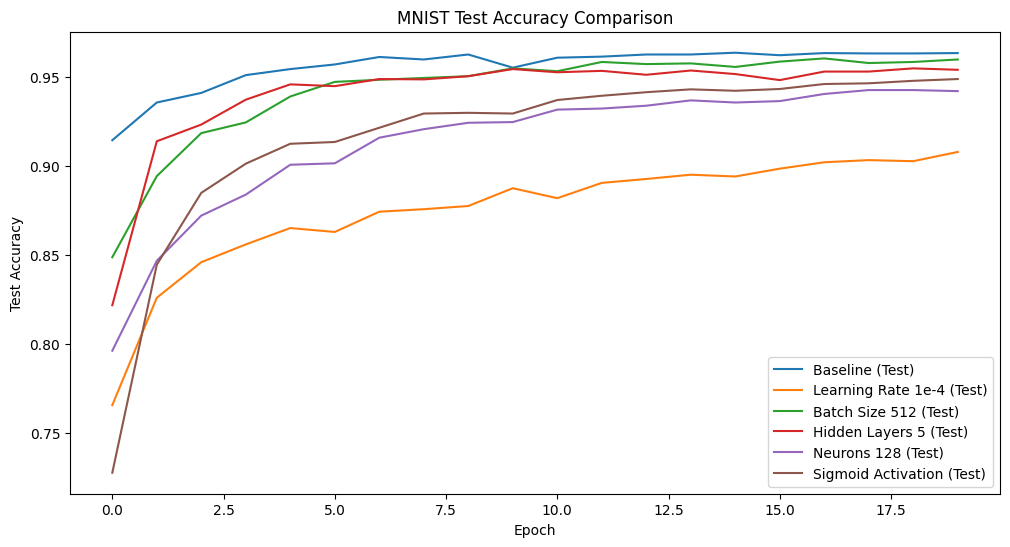

![HW5 - Q2train.png](<attachment:HW5 - Q2train.png>)
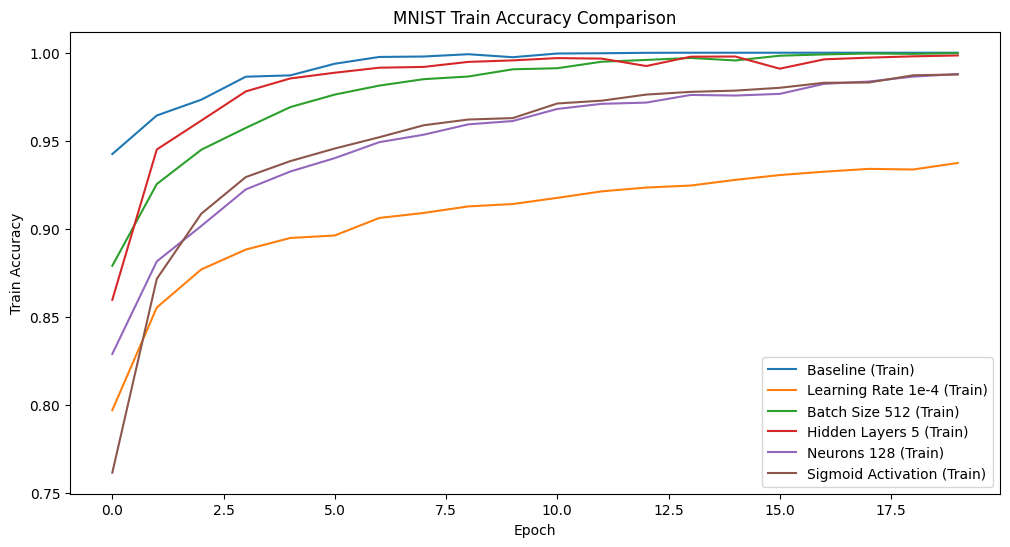


## Q3 (10 Points) - ReLU Regression & Hold-out MSE

We studied underfitting, overfitting, and good generalization using polynomial regression in HW2. In this example, we train ReLU Deep Neural Networks (DNNs).

**Problem Tasks:**

(a)
1. In one figure with 3 subplots, fit one hidden layer ReLU DNNs of widths 20, 500 and 2000, respectively. Label them as underfit, overfit, or good fit.

2. Compute the hold-out mean squared error (MSE) for each width and display it on the subplot.

(b)

1. For the example from (a) that demonstrates underfit, you keep the same width, and augment the ReLU DNN with depths of 1,4 and 7 layers. Train these DNNs.

2. Compute the hold-out mean squared error (MSE) for each depth and display it on the subplot.

(c)
1. In a few sentences, interpret the results: How do model complexity and generalization (predictive accuracy) trade off?



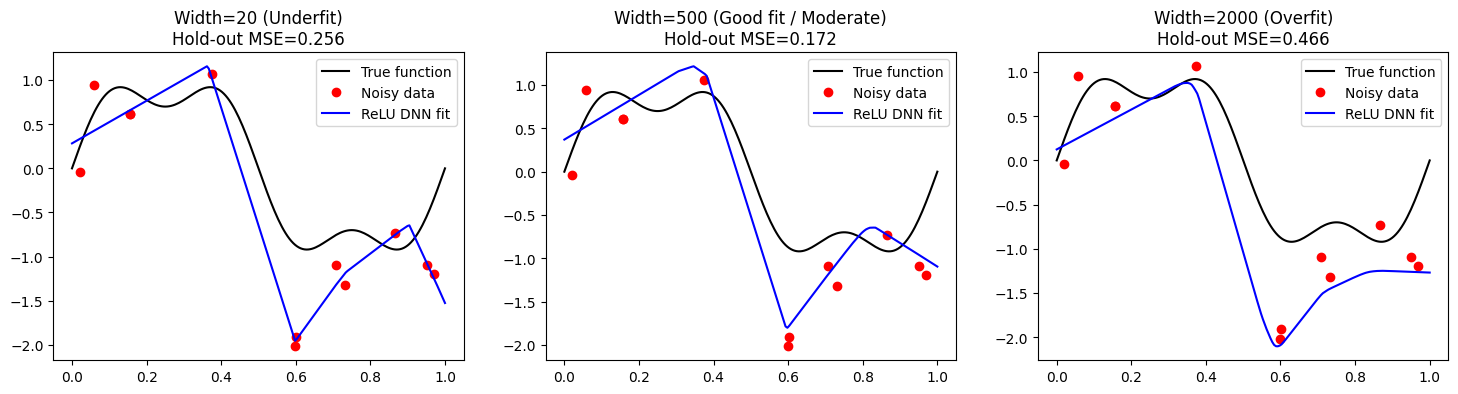

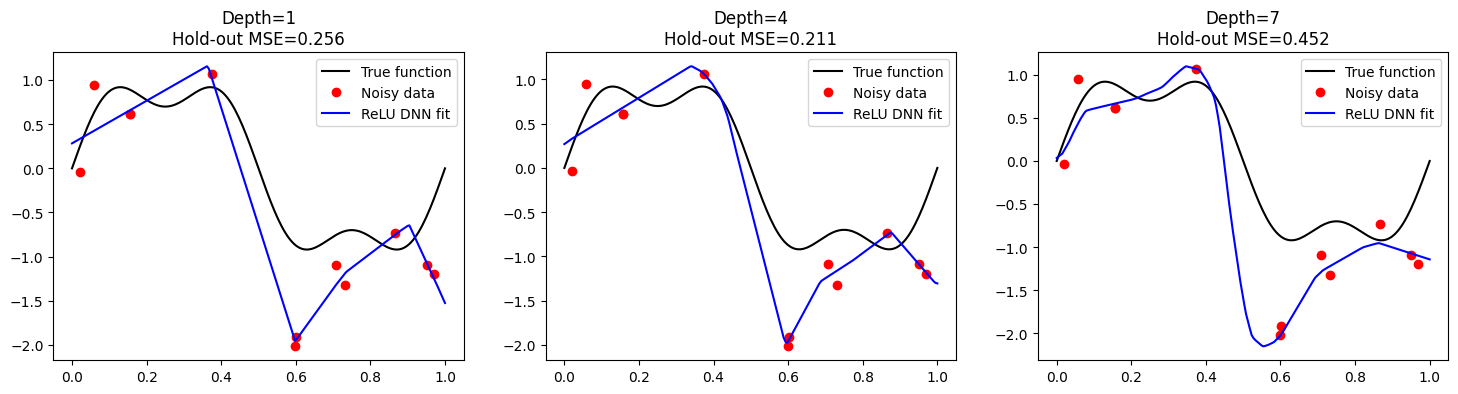

In [4]:
# one-hidden layer ReLU networks

import numpy as np
import matplotlib.pyplot as plt
from sklearn.neural_network import MLPRegressor
from sklearn.metrics import mean_squared_error

np.random.seed(42)

# --------------------------------------------------------------
# True smooth function
# --------------------------------------------------------------
def true_fn(x):
    return np.sin(2 * np.pi * x) + 0.3 * np.sin(6 * np.pi * x)

# --------------------------------------------------------------
# Very small training data + heavy noise
# --------------------------------------------------------------
X = np.sort(np.random.rand(12))
y = true_fn(X) + 0.6 * np.random.randn(12)   # large noise

# Hold-out (dense grid, nearly noise-free)
Xh = np.linspace(0, 1, 200)
yh = true_fn(Xh)

# Reshape for sklearn
X_train = X.reshape(-1, 1)
X_holdout = Xh.reshape(-1, 1)

# Visualization grid
xx = np.linspace(0, 1, 400)
X_grid = xx.reshape(-1, 1)

widths = [20, 500, 2000]

# for the one-hidden layer ReLU use MLPRegressor from sklearn with activation set to relu.
# For all problems in this question, use below model of below template:
#  model = MLPRegressor(
#       hidden_layer_sizes=(width,),
#       activation='relu',
#       solver='adam',
#       alpha=0.0,
#       learning_rate = 'constant',
#       learning_rate_init=0.01,
#       batch_size=len(X_train),
#       max_iter=8000,
#       tol=0,
#       shuffle=False,
#       random_state=0
#   )

# hidden_layer_sizes would vary for each problem (depending on width and depth of network) in this question.
# All the other parameters (solver, alpha, learning_rate_init, etc) are to be unchanged.

# 1a
fig, axes = plt.subplots(1, 3, figsize=(18, 4))
widths = [20, 500, 2000]
labels = ['Underfit', 'Good fit / Moderate', 'Overfit']  # intuitive labels
for i, width in enumerate(widths):
    # Create ReLU MLP
    model = MLPRegressor(
        hidden_layer_sizes=(width,),
        activation='relu',
        solver='adam',
        alpha=0.0,
        learning_rate='constant',
        learning_rate_init=0.01,
        batch_size=len(X_train),
        max_iter=8000,
        tol=0,
        shuffle=False,
        random_state=0
    )
    # Fit model
    model.fit(X_train, y)
    # Predict on hold-out
    y_pred = model.predict(X_holdout)
    # Compute hold-out MSE
    mse = mean_squared_error(yh, y_pred)
    # Plot
    ax = axes[i]
    ax.plot(Xh, yh, label='True function', color='black')
    ax.plot(X_train, y, 'o', label='Noisy data', color='red')
    ax.plot(Xh, y_pred, label='ReLU DNN fit', color='blue')
    ax.set_title(f'Width={width} ({labels[i]})\nHold-out MSE={mse:.3f}')
    ax.legend()
plt.show()

# 1b
depths = [1, 4, 7]
fig, axes = plt.subplots(1, 3, figsize=(18, 4))
for i, depth in enumerate(depths):
    # Hidden layer sizes = tuple of length 'depth' all with width=20
    hidden_sizes = tuple([20] * depth)
    model = MLPRegressor(
        hidden_layer_sizes=hidden_sizes,
        activation='relu',
        solver='adam',
        alpha=0.0,
        learning_rate='constant',
        learning_rate_init=0.01,
        batch_size=len(X_train),
        max_iter=8000,
        tol=0,
        shuffle=False,
        random_state=0
    )
    # Fit model
    model.fit(X_train, y)
    # Predict on hold-out
    y_pred = model.predict(X_holdout)
    # Compute hold-out MSE
    mse = mean_squared_error(yh, y_pred)
    # Plot
    ax = axes[i]
    ax.plot(Xh, yh, label='True function', color='black')
    ax.plot(X_train, y, 'o', label='Noisy data', color='red')
    ax.plot(Xh, y_pred, label='ReLU DNN fit', color='blue')
    ax.set_title(f'Depth={depth}\nHold-out MSE={mse:.3f}')
    ax.legend()
plt.show()



1c. Model complexity controls the expressive power of the network: small width/depth → underfit, large width/depth → overfit. The trade-off here occurs when increasing complexity allows the network to fit the training data more closely, which reduces training error but may increase hold-out error if the model memorizes the training data or noise. Good generalization occurs at an intermediate complexity, where the network captures the true underlying function but not the noise. This moderate fit is the right point in the trade-off between over and underfitting.

## Q4 (10 Points) — Ridge (L2) vs Lasso (L1) in ReLU DNNs on Diabete data set

We compare the effects of L2 (Ridge-style) and L1 (Lasso-style) regularization on a one-hidden-layer ReLU neural network trained on the Diabetes dataset. We vary the regularization strength $\alpha$ and analyze the behavior of learned weights and test-set performance.

**Problem Tasks:**

1. (8 pts) Train one-hidden-layer ReLU DNN of width 20 neurons with L2 and L1 regularization across a grid of $\alpha$ values (on a log scale).
For each regularization, plot the magnitude of first-layer weights as a function of $\alpha$. Use side-by-side subplots to compare and discuss the two results.

2. (6 pts) Pick a reasonable $\alpha$ for Ridge and Lasso each (justify briefly), fit on a 70/30 train/test split, and report the test MSE for both.



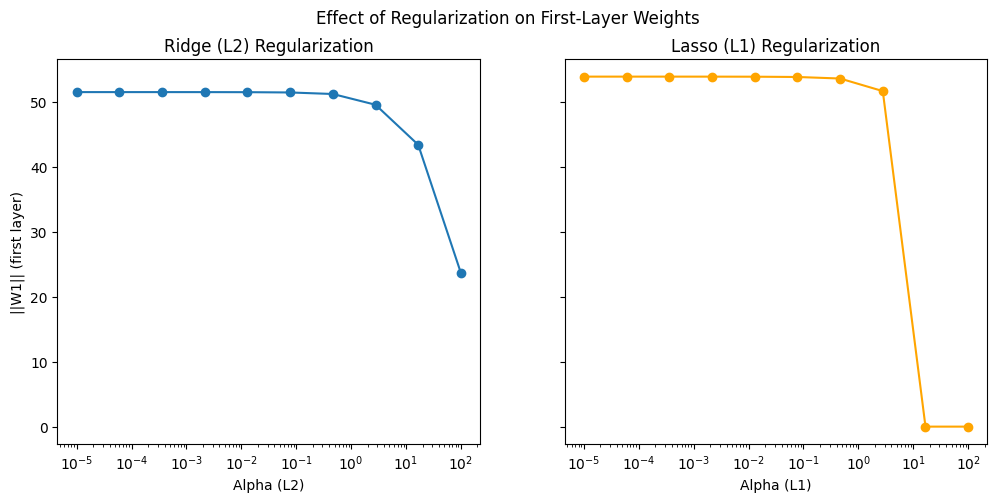

Optimal alpha (Ridge): 16.68101, Test MSE: 2998.847
Optimal alpha (Lasso): 16.68101, Test MSE: 2998.847


In [5]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_diabetes
from sklearn.neural_network import MLPRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error
import warnings
from sklearn.exceptions import ConvergenceWarning
warnings.filterwarnings("ignore", category=ConvergenceWarning)

# ==========================================================================================
# Loading data
X_d, y_d = load_diabetes(return_X_y=True)
alphas = np.logspace(-5, 2, 10)  # search grid for alpha

# ==========================================================================================
# Training, validation and test data
Xtr, Xte, ytr, yte = train_test_split(X_d, y_d, test_size=0.3, random_state=0)
X_train, X_val, y_train, y_val = train_test_split(Xtr, ytr, test_size=0.2, random_state=0)
# ==========================================================================================

# We use the MLPRegressor ReLU network from sklearn.neural_network as in the earlier problems (you can choose any parameter values (solver, learning_rate_init, max_iter, etc))
# one each for L1 and L2-regularization value experiments.

# Unlike Lasso and Ridge from sklearn.linear_model (used in HW2) MLPRegressor doesn't have:
# 1. Inbuilt varying L1-regularization.
# 2. Methods such as LassoCV and RidgeCV to perform cross-validation to determine optimum regularization values. This is because Lasso and Ridge are
# convex optimization problems and consequently admit computing coefficient paths. Neural networks are non-convex and so, optimum regularization values are determined
# using empirical validation.

# Dealing with the above 2 properties of neural networks:

# 1. L1-regularization in neural networks:
# To mimic L1-regularization on neural networks, the parameters associated with a trained network are penalized by setting values below a threshold to zero:

#    weights_all = np.concatenate([np.abs(W.ravel()) for W in model_l1.coefs_])
#    weights_all[weights_all < alpha] = 0
#    l1_weights.append(weights_all)

# where model_l1 is the model being trained using various L1-regularization values alpha.
# l1_weights is a list that preserves the weights associated with varying alpha values.


# 2. Performing empirical validation:
#  To do this, loss values are computed on the validation dataset (X_val, y_val) during the course of training and the regularization values
# associated with the lowest validation loss are selected as the optimum values:

#    val_pred = model.predict(X_val)
#    val_mse.append(mean_squared_error(y_val, val_pred))

# where model is the MLPRegressor corresponding to certain regularization value (alpha), both L1 and L2-regularization cases.
# The alpha value corresponding to the lowest val_mse is selected as the optimum regularization value.


# Finally, test losses are computed on the test dataset (Xte, yte) using the optimum alpha values:
# mse_l2 = mean_squared_error(yte, model_final.predict(Xte))
# where model_final is the model with the selected optimum regularization value.

hidden_layer_size = 20

ridge_weights = []
lasso_weights = []
val_mse_l2 = []
val_mse_l1 = []

for alpha in alphas:
    model_l2 = MLPRegressor(
        hidden_layer_sizes=(hidden_layer_size,),
        activation='relu',
        solver='adam',
        alpha=alpha,
        max_iter=5000,
        random_state=42
    )
    model_l2.fit(X_train, y_train)
    
    # First-layer weight magnitude
    w1_norm = np.linalg.norm(model_l2.coefs_[0])
    ridge_weights.append(w1_norm)
    
    # Validation MSE
    val_pred = model_l2.predict(X_val)
    val_mse_l2.append(mean_squared_error(y_val, val_pred))
    
    model_l1 = MLPRegressor(
        hidden_layer_sizes=(hidden_layer_size,),
        activation='relu',
        solver='adam',
        alpha=alpha,      # base alpha (used with thresholding)
        max_iter=5000,
        random_state=42
    )
    model_l1.fit(X_train, y_train)
    
    # Collect all weights
    weights_all = np.concatenate([np.abs(W.ravel()) for W in model_l1.coefs_])
    # Threshold small weights to mimic L1 sparsity
    weights_all[weights_all < alpha] = 0
    l1_weights_norm = np.linalg.norm(weights_all)
    lasso_weights.append(l1_weights_norm)
    
    # Validation MSE
    val_pred = model_l1.predict(X_val)
    val_mse_l1.append(mean_squared_error(y_val, val_pred))

# Plot the magnitude of first-layer weights vs alpha
fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharey=True)

axes[0].plot(alphas, ridge_weights, marker='o')
axes[0].set_xscale('log')
axes[0].set_xlabel('Alpha (L2)')
axes[0].set_ylabel('||W1|| (first layer)')
axes[0].set_title('Ridge (L2) Regularization')

axes[1].plot(alphas, lasso_weights, marker='o', color='orange')
axes[1].set_xscale('log')
axes[1].set_xlabel('Alpha (L1)')
axes[1].set_title('Lasso (L1) Regularization')

plt.suptitle('Effect of Regularization on First-Layer Weights')
plt.show()

# Select reasonable alpha based on validation MSE and evaluate test performance
alpha_ridge_best = alphas[np.argmin(val_mse_l2)]
alpha_lasso_best = alphas[np.argmin(val_mse_l1)]

# Train final models on full training data (Xtr, ytr)
model_ridge_final = MLPRegressor(
    hidden_layer_sizes=(hidden_layer_size,),
    activation='relu',
    solver='adam',
    alpha=alpha_ridge_best,
    max_iter=5000,
    random_state=42
)
model_ridge_final.fit(Xtr, ytr)
mse_l2 = mean_squared_error(yte, model_ridge_final.predict(Xte))

model_lasso_final = MLPRegressor(
    hidden_layer_sizes=(hidden_layer_size,),
    activation='relu',
    solver='adam',
    alpha=alpha_lasso_best,
    max_iter=5000,
    random_state=42
)
model_lasso_final.fit(Xtr, ytr)
# Apply thresholding to mimic L1 sparsity
weights_all = np.concatenate([np.abs(W.ravel()) for W in model_lasso_final.coefs_])
weights_all[weights_all < alpha_lasso_best] = 0
mse_l1 = mean_squared_error(yte, model_lasso_final.predict(Xte))

print(f"Optimal alpha (Ridge): {alpha_ridge_best:.5f}, Test MSE: {mse_l2:.3f}")
print(f"Optimal alpha (Lasso): {alpha_lasso_best:.5f}, Test MSE: {mse_l1:.3f}")

As alpha increases, for L2 (Ridge) regularization, the norm of the first-layer weights decreases smoothly. The decrease is gradual showing the shrinking effect of L2. L2 penalizes the square of weight magnitudes, which discourages large weights but preserves all features. On the contrary, for L1 (Lasso) regularization, the first-layer weight norm drops more sharply. The decrease is sudden which shows the sparse nature of L1 regularization. L1 encourages sparse networks by performing feature selection and removing less important weights.

## Q5 (40 Points) — Function Approximation with ReLU and tanh DNNs

In this problem, we approximate the polynomial function from noisy data points using **neural networks** with **ReLU** and **tanh** activations.  
We will investigate how **network depth** and **regularization** affect underfitting and overfitting behavior.

---

### Problem Setup

We generate data pair $(x^{(i)}, y^{(i)})$ from the following noise-corrupted relation  
<!-- $$
f(x^{(i)}) = 0.5 - {x^{(i)}} - 0.5 [{x^{(i)}}]^2 - 2 [{x^{(i)}}]^3 + 5 [{x^{(i)}}]^4
$$ -->

$$
f(x^{(i)}) = 0.5\sin{2{\pi}x^{(i)}} +0.3x + 0.1[{x^{(i)}}]^2
$$

$$ y^{(i)} = f(x^{(i)}) + \delta\mathcal{N}(0,1)$$
of the following  ground truth function
$$ y = 0.5\sin{2{\pi}x} + 0.3x + 0.1x^2$$


where $\delta = 0.05$ is the noise level and $\varphi^{(i)} \sim \mathcal{N}(0, 1)$.  
We generate **15 holdout samples** and **15 training samples** uniformly spaced on  x $\in$ \([0, 1]\).

---

### Tasks

#### (1.a)
Generate the dataset and visualize:
- The true function \(f(x)\)
- The noisy training samples
- The holdout samples

Plot all three on the same figure.

---

#### (1.b)
Train three **ReLU DNNs** with one hidden layer but different **depths** (number of layers) and fixed **width**:

For the ReLU network:

depths_relu = [1, 6, 8]

width_relu = 10

model = MLPRegressor( hidden_layer_sizes=(width_relu,)*d, activation='relu',
                       solver='adam', learning_rate_init=0.01, alpha=0.0, max_iter=20000, random_state=0)

where d is the depth.

Plot the predicted curves vs. the true function and training data.  
Report the **MSE on holdout data** and identify which model underfits, fits well, and overfits.

---

#### (1.c)
For the **overfitting ReLU network**, apply **L2 regularization** using the `alpha` parameter in `MLPRegressor`.

1. Plot model predictions for several values of $\alpha$ over the range $\alpha \in [10^{-5},10]$.  
2. Plot the **holdout MSE** as a function of $\alpha$.  
3. Identify the value of $\alpha$ that balances bias and variance.

---

#### (1.d)
Repeat (1.c) for **L1-like regularization**, approximated by thresholding small weights post-training to simulate sparsity.  
Compare how **L1** and **L2** affect the smoothness and shape of the learned function.

---

#### (1.e)
Repeat parts (1.b)-(1.d) using **tanh activation** instead of ReLU.  

For the tanh network:

depths_tanh = [1, 8,  12]

width_tanh = 25

model = MLPRegressor(hidden_layer_sizes=(width_tanh,)*d, activation='tanh', learning_rate_init=0.01, alpha=0.0, solver='adam', max_iter=20000, random_state=0)

where d is the depth.

Discuss the differences in:
- Smoothness of the learned function,
- Overfitting behavior,
- Sensitivity to depth and regularization.

---

#### (1.f) — *Data Augmentation as Regularization*
To further mitigate overfitting, apply a **data augmentation** approach:

1. Clone the 15 training samples into 300 duplicates using `numpy.repeat`. (Note: this is noise-free data).  
2. Add Gaussian noise to these samples:
$$
   \tilde{x}^{(i)} = x^{(i)} + \delta \varphi^{(i)}, \quad \varphi^{(i)} \sim \mathcal{N}(0,1), \delta = 0.02$$
3. Train your best ReLU and tanh DNNs on this **augmented dataset**.  
4. Compare the fits and **holdout MSE** before and after augmentation.

Discuss how data augmentation acts as an **implicit regularizer**.


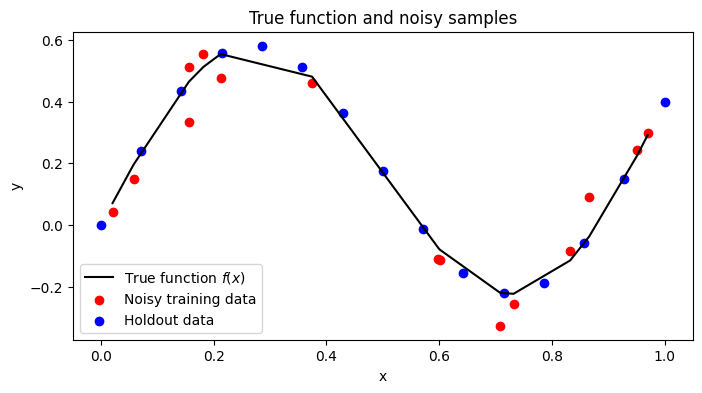

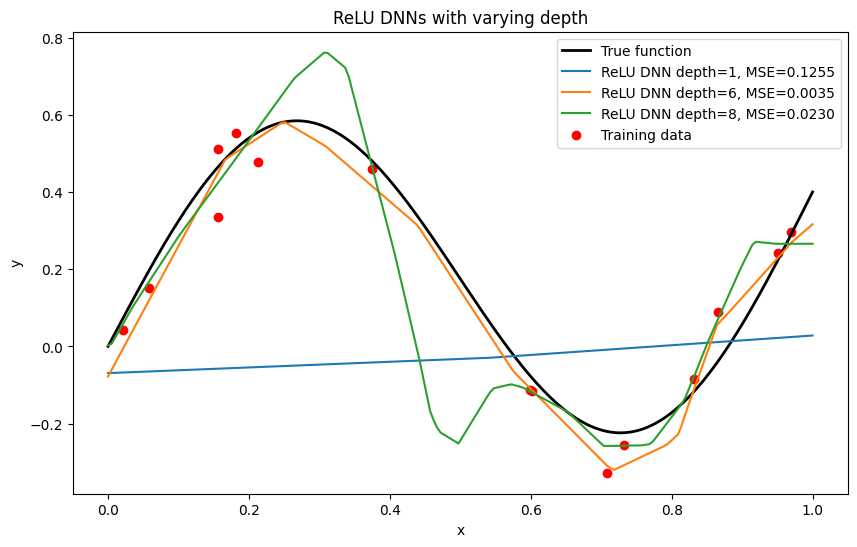

Holdout MSEs: {1: 0.12552475750862435, 6: 0.003474681132763004, 8: 0.022969232867571153}


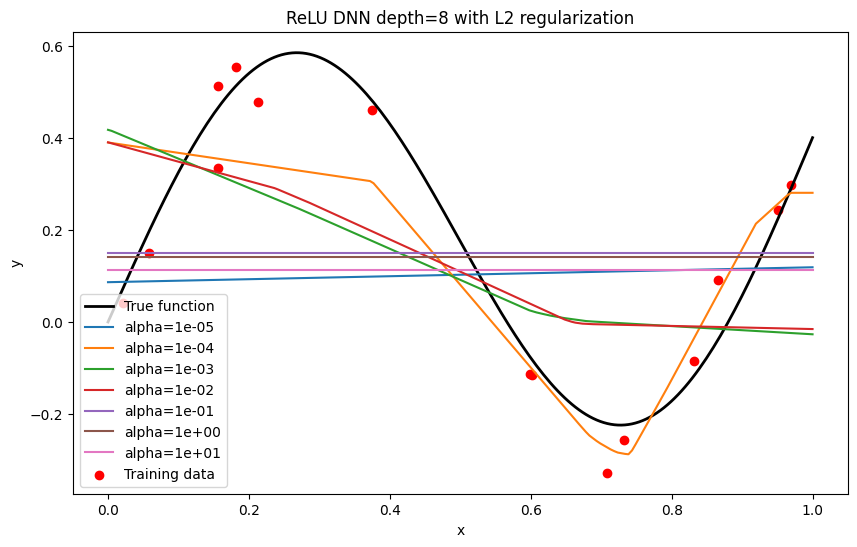

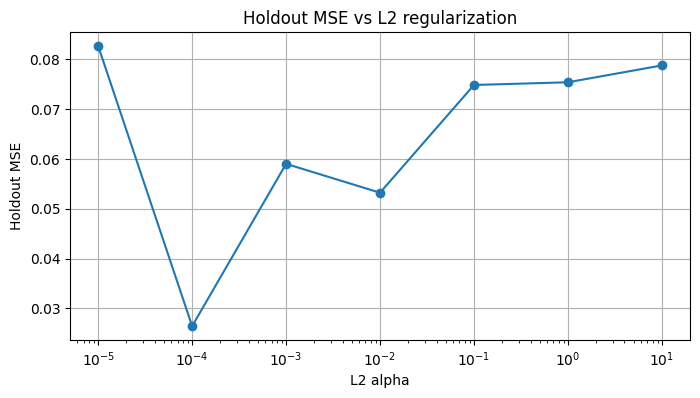

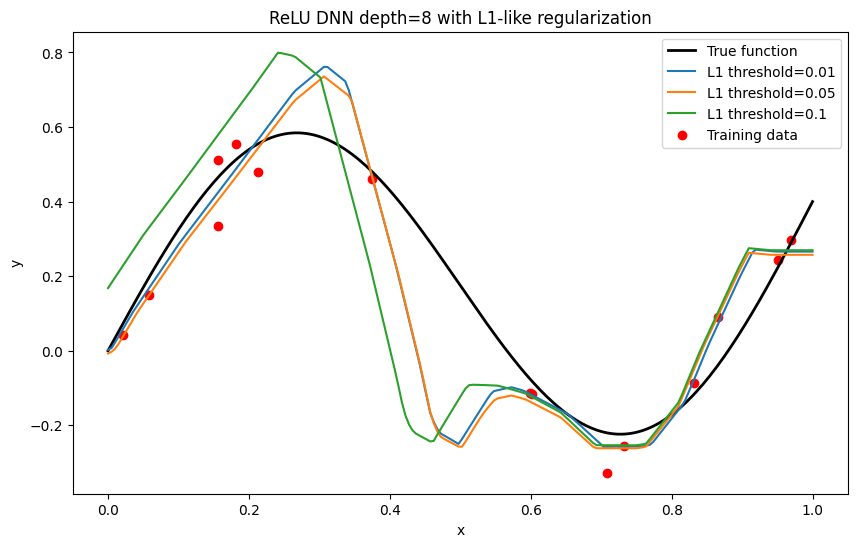

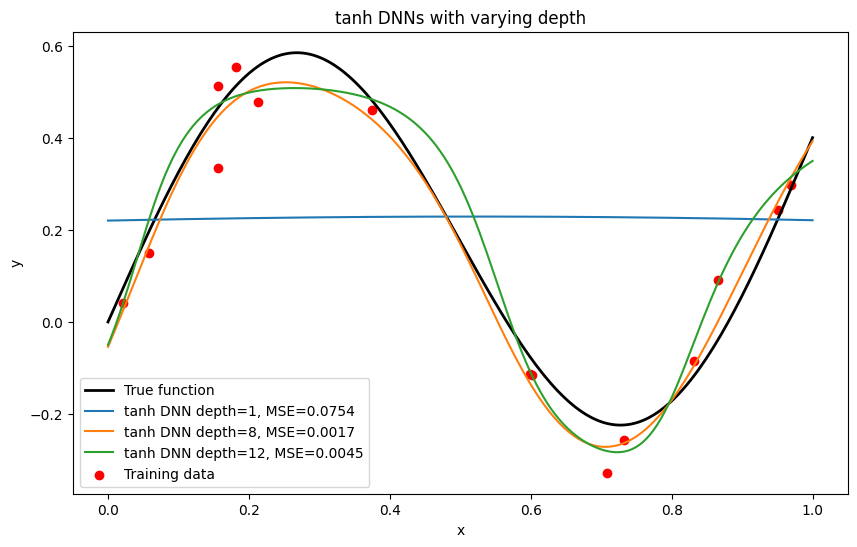

Holdout MSEs: {1: 0.07540238055262312, 8: 0.0016937010485400536, 12: 0.004501852445850165}
Holdout MSE after ReLU augmentation: 0.0029263931375404706
Holdout MSE after tanh augmentation: 0.002867082415465614


In [8]:
import warnings
warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", category=UserWarning)
warnings.filterwarnings("ignore")

import numpy as np
import matplotlib.pyplot as plt
from sklearn.neural_network import MLPRegressor
from sklearn.metrics import mean_squared_error

np.random.seed(42)
plt.rcParams['figure.figsize'] = [8, 4]

# =============================================================
# True function and noisy training data
# =============================================================
def true_fn(x):
    """Smooth nonlinear function."""
    return 0.5*np.sin(2*np.pi*x) + 0.3*x + 0.1*x**2

# training set with noise
delta = 0.05
n_train_samples = 15
X_train = np.sort(np.random.rand(n_train_samples))
y_train = true_fn(X_train)
y_train_noisy = y_train + delta*np.random.randn(n_train_samples)  # small additive noise

# Dense holdout for evaluation
n_holdout_samples = 15
X_holdout = np.linspace(0, 1, n_holdout_samples)
y_holdout = true_fn(X_holdout)

# ==========================================================================================
# Visualization of the data
# ==========================================================================================
x_plot = np.linspace(0, 1, 200)
y_true_plot = true_fn(x_plot)

plt.figure()
plt.plot(X_train, y_train, 'k-', label='True function $f(x)$')
plt.scatter(X_train, y_train_noisy, color='r', label='Noisy training data')
plt.scatter(X_holdout, y_holdout, color='b', label='Holdout data')
plt.xlabel("x")
plt.ylabel("y")
plt.title("True function and noisy samples")
plt.legend()
plt.show()

# ==========================================================================================
# [CONTINUE YOUR WORK FROM HERE!]
# You will:
#   • Train ReLU and tanh DNNs with varying depths
#   • Explore underfit / good fit / overfit
#   • Apply L2 and L1 regularization
#   • Perform data augmentation
# ==========================================================================================

# For the ReLU network:
# depths_relu = [1, 6, 8]
# width_relu = 10
# model = MLPRegressor( hidden_layer_sizes=(width_relu,)*d, activation='relu',
#                       solver='adam', learning_rate_init=0.01, alpha=0.0, max_iter=20000, random_state=0)

# where d is the depth.

# For the tanh network:
# depths_tanh = [1, 8,  12]
# width_tanh = 25 # tanh
# model = MLPRegressor(hidden_layer_sizes=(width_tanh,)*d, activation='tanh', learning_rate_init=0.01,
#                     alpha=0.0, solver='adam', max_iter=20000, random_state=0)
# where d is the depth

#1b
depths_relu = [1, 6, 8]
width_relu = 10

plt.figure(figsize=(10,6))
plt.plot(x_plot, y_true_plot, 'k-', label='True function', linewidth=2)

holdout_mse_relu = []

for d in depths_relu:
    model = MLPRegressor(hidden_layer_sizes=(width_relu,)*d,
                         activation='relu', solver='adam',
                         learning_rate_init=0.01, alpha=0.0,
                         max_iter=20000, random_state=0)
    model.fit(X_train.reshape(-1,1), y_train_noisy)
    
    y_pred = model.predict(x_plot.reshape(-1,1))
    y_holdout_pred = model.predict(X_holdout.reshape(-1,1))
    mse = mean_squared_error(y_holdout, y_holdout_pred)
    holdout_mse_relu.append(mse)
    
    plt.plot(x_plot, y_pred, label=f'ReLU DNN depth={d}, MSE={mse:.4f}')

plt.scatter(X_train, y_train_noisy, color='r', label='Training data')
plt.xlabel('x'); plt.ylabel('y'); plt.title('ReLU DNNs with varying depth')
plt.legend()
plt.show()

print("Holdout MSEs:", dict(zip(depths_relu, holdout_mse_relu)))

#1c
alphas = np.logspace(-5, 1, 7)  # [1e-5, 1e-4, ..., 10]
holdout_mse_l2 = []

plt.figure(figsize=(10,6))
plt.plot(x_plot, y_true_plot, 'k-', label='True function', linewidth=2)

for alpha in alphas:
    model = MLPRegressor(hidden_layer_sizes=(width_relu,)*8,
                         activation='relu', solver='adam',
                         learning_rate_init=0.01, alpha=alpha,
                         max_iter=20000, random_state=0)
    model.fit(X_train.reshape(-1,1), y_train_noisy)
    y_pred = model.predict(x_plot.reshape(-1,1))
    y_holdout_pred = model.predict(X_holdout.reshape(-1,1))
    holdout_mse_l2.append(mean_squared_error(y_holdout, y_holdout_pred))
    
    plt.plot(x_plot, y_pred, label=f'alpha={alpha:.0e}')

plt.scatter(X_train, y_train_noisy, color='r', label='Training data')
plt.xlabel('x'); plt.ylabel('y'); plt.title('ReLU DNN depth=8 with L2 regularization')
plt.legend()
plt.show()

plt.figure()
plt.semilogx(alphas, holdout_mse_l2, marker='o')
plt.xlabel('L2 alpha'); plt.ylabel('Holdout MSE')
plt.title('Holdout MSE vs L2 regularization')
plt.grid(True)
plt.show()

#1d
def apply_l1_threshold(model, threshold=1e-2):
    """Zero out weights smaller than threshold to simulate L1."""
    for coef in model.coefs_:
        coef[np.abs(coef) < threshold] = 0
    return model

thresholds = [0.01, 0.05, 0.1]
plt.figure(figsize=(10,6))
plt.plot(x_plot, y_true_plot, 'k-', label='True function', linewidth=2)

for t in thresholds:
    model = MLPRegressor(hidden_layer_sizes=(width_relu,)*8,
                         activation='relu', solver='adam',
                         learning_rate_init=0.01, alpha=0.0,
                         max_iter=20000, random_state=0)
    model.fit(X_train.reshape(-1,1), y_train_noisy)
    model = apply_l1_threshold(model, threshold=t)
    y_pred = model.predict(x_plot.reshape(-1,1))
    plt.plot(x_plot, y_pred, label=f'L1 threshold={t}')

plt.scatter(X_train, y_train_noisy, color='r', label='Training data')
plt.xlabel('x'); plt.ylabel('y'); plt.title('ReLU DNN depth=8 with L1-like regularization')
plt.legend()
plt.show()

#1e
depths_tanh = [1, 8, 12]
width_tanh = 25
holdout_mse_tanh = []

plt.figure(figsize=(10,6))
plt.plot(x_plot, y_true_plot, 'k-', label='True function', linewidth=2)

for d in depths_tanh:
    model = MLPRegressor(hidden_layer_sizes=(width_tanh,)*d,
                         activation='tanh', solver='adam',
                         learning_rate_init=0.01, alpha=0.0,
                         max_iter=20000, random_state=0)
    model.fit(X_train.reshape(-1,1), y_train_noisy)
    y_pred = model.predict(x_plot.reshape(-1,1))
    y_holdout_pred = model.predict(X_holdout.reshape(-1,1))
    holdout_mse_tanh.append(mean_squared_error(y_holdout, y_holdout_pred))
    plt.plot(x_plot, y_pred, label=f'tanh DNN depth={d}, MSE={holdout_mse_tanh[-1]:.4f}')

plt.scatter(X_train, y_train_noisy, color='r', label='Training data')
plt.xlabel('x'); plt.ylabel('y'); plt.title('tanh DNNs with varying depth')
plt.legend()
plt.show()

print("Holdout MSEs:", dict(zip(depths_tanh, holdout_mse_tanh)))

#1f
X_aug = np.repeat(X_train, 20)
y_aug = np.repeat(y_train_noisy, 20)
X_aug += 0.02*np.random.randn(len(X_aug))

model_relu_aug = MLPRegressor(hidden_layer_sizes=(width_relu,)*6,
                              activation='relu', solver='adam',
                              learning_rate_init=0.01, alpha=0.0,
                              max_iter=20000, random_state=0)
model_relu_aug.fit(X_aug.reshape(-1,1), y_aug)
y_holdout_pred = model_relu_aug.predict(X_holdout.reshape(-1,1))
mse_aug = mean_squared_error(y_holdout, y_holdout_pred)
print("Holdout MSE after ReLU augmentation:", mse_aug)

model_tanh_aug = MLPRegressor(hidden_layer_sizes=(width_tanh,)*8,
                              activation='tanh', solver='adam',
                              learning_rate_init=0.01, alpha=0.0,
                              max_iter=20000, random_state=0)
model_tanh_aug.fit(X_aug.reshape(-1,1), y_aug)
y_holdout_pred_tanh = model_tanh_aug.predict(X_holdout.reshape(-1,1))
mse_aug_tanh = mean_squared_error(y_holdout, y_holdout_pred_tanh)
print("Holdout MSE after tanh augmentation:", mse_aug_tanh)



1b. depth = 1: Underfits, depth = 6: Fits Well, depth = 8: Overfits

1d. The difference in the shape of the learned function for l1 and l2 regularization exists because of how they work. Lasso regularization produces sparse weights which could potentially give a smoother function but it can underfit. Since the weights are zeroed out in L1, the model compelxity is reduced. On the contrary, L2 spreads the penalty across the weights. 

1e. Tanh used as an activation is naturally smooth which results in the smoother curves visulized compared to piecewise ReLU. Deep tanh networks still can overfit when the dataset is small. If you increase the depth, you may risk overfitting the training data but L2 regulariztion can help stabilize. 

1f. By duplicating training points and adding small noise, we increase the dataset size. Exposing the network to slightly perturbed inputs forces it to learn patterns rather than memorizing data points. In general, the effect is that we see overfitting less in ReLU or tanh netoworks. Data augmentation is an implicit regularization technique by acting as a bias towards smoother functions. This is very similar to L2.

## Question 6 (10 Points) (Probabilistic Regression with a Neural Network)


We now revisit the probabilistic regression problem from HW3 (Question 5), but instead of using polynomial regression, we will use a **Deep Neural Network (DNN)** to model the conditional distribution of $y$ given $x$.

Consider the following nonlinear function:
$$
y = f(x) = a_4x^4 + a_3x^3 + a_2x^2 + a_1x + a_0
$$
with coefficients:
$$
[a_0,a_1,a_2,a_3,a_4] = [0.5, -1.0, -0.5, -2.0, 5.0].
$$

---

### (i) Data Generation

1. Choose values for $N$ and $\delta$.
2. Draw $N$ input samples $x^{(i)} \sim \mathcal{N}(0, 2)$.
3. Generate noisy observations:
   $$
   y^{(i)} = f(x^{(i)}) + \epsilon^{(i)}, \quad \epsilon^{(i)} \sim \mathcal{N}(0, \delta^2).
   $$
4. Visualize the true function $f(x)$, the noisy training data, and several new samples of $x$ to understand the variability.

---

### (ii) Gaussian Likelihood Model using a Neural Network

We assume the following conditional model:
$$
P(y | x, \boldsymbol{\theta}) = \mathcal{N}\big(\mu_\theta(x), \sigma^2\big)
$$
where:
- $\mu_\theta(x)$ is the **mean predicted by a DNN** (your choice of architecture, e.g., 2 hidden layers, ReLU activation).
- $\sigma = \delta$ is fixed (same as the noise level used to generate data).

Use the **maximum likelihood estimation (MLE)** principle to find the optimal parameters:
$$
\boldsymbol{\theta}^* = \arg\max_\theta \sum_{i=1}^N \log P(y^{(i)} | x^{(i)}, \boldsymbol{\theta})
$$

**Tasks:**
- Implement the DNN model (using `sklearn.MLPRegressor`).
- Write a training loop to minimize the negative log-likelihood:
  $$
  \mathcal{L}(\theta) = \frac{1}{2\sigma^2} \sum_i (y^{(i)} - \mu_\theta(x^{(i)}))^2 + \frac{N}{2}\log(2\pi\sigma^2)
  $$
- Train your model and plot the predicted mean vs. the true function and training data.

---

### (iii) Confidence Band Visualization

Since $P(y|x,\theta^*)$ is Gaussian with mean $\mu_\theta(x)$ and fixed variance $\sigma^2$:
- Plot the mean prediction curve.
- Add the uncertainty bands corresponding to one standard deviation:
  $$
  y = \mu_\theta(x) \pm \sigma
  $$
- Discuss how well the model captures the variability in the data.

---

### (iv) Probabilistic Coverage Test

Now draw **50 new test samples**:
$$
x^{(i)} \sim \mathcal{N}(0, 2), \quad y^{(i)} = f(x^{(i)}) + \epsilon^{(i)}.
$$
Plot these 50 test points on top of your uncertainty bands from (iii).

Compute the **percentage of points that fall within the $\pm\sigma$** region of the mean prediction.  
Discuss whether this percentage is close to the theoretical 68% expected for a Gaussian distribution.

---

### (v) MAP Estimation (with Weight Regularization)

Now modify the likelihood by adding a **Gaussian prior** on the network parameters:
$$
P(\theta) \propto \exp\left(-\frac{1}{2\tau^2} \|\theta\|^2\right)
$$
leading to a **MAP optimization problem**:
$$
\boldsymbol{\theta}^*_{MAP} = \arg\max_\theta \log P(y|x,\theta) + \log P(\theta)
$$
which is equivalent to adding **L2 regularization** in your loss function.

**Tasks:**
- Train the same DNN architecture but include weight decay (`alpha` or `weight_decay` parameter).
- Plot the new mean prediction and confidence bands.
- Compare them with the MLE results.

---

### (vi) Discussion

Compare the **MLE** and **MAP** results:
- Which approach gives smoother predictions?
- Which captures the true function better?
- How does regularization (the prior) affect the uncertainty band?


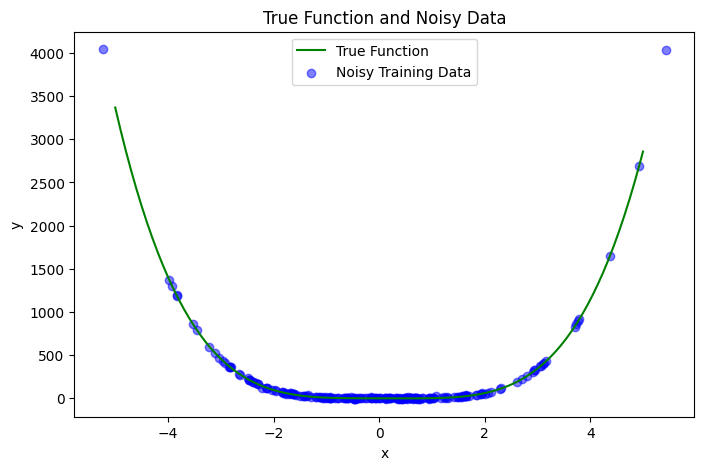

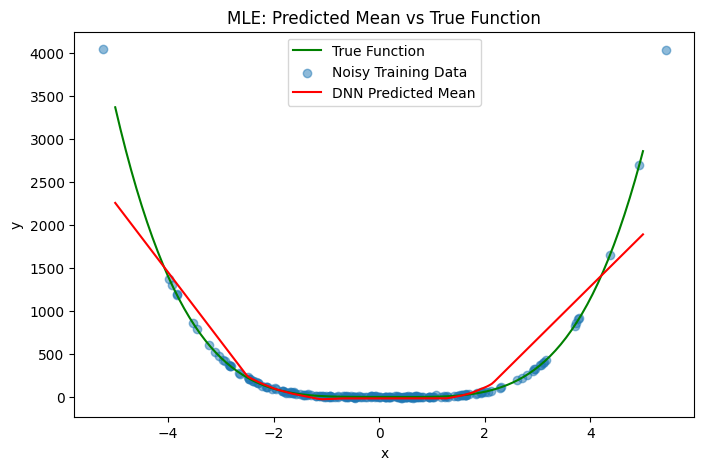

Estimated sigma from residuals: 208.68


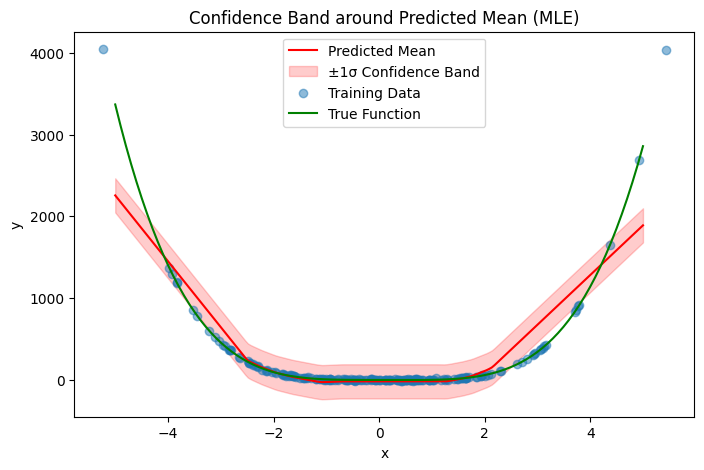

Percentage of test points within ±estimated sigma: 84.00%


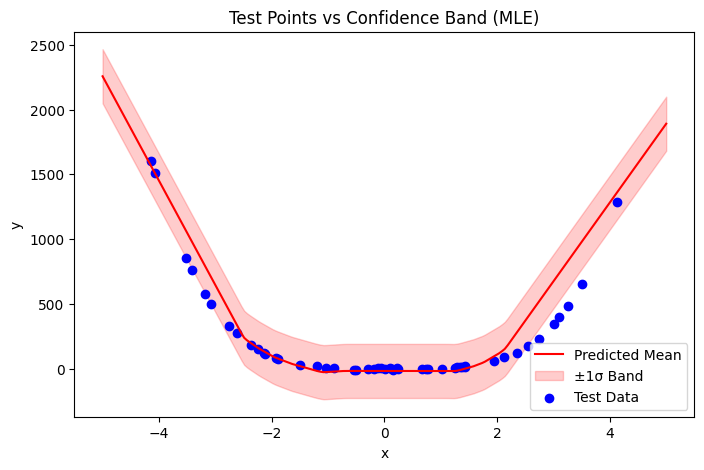

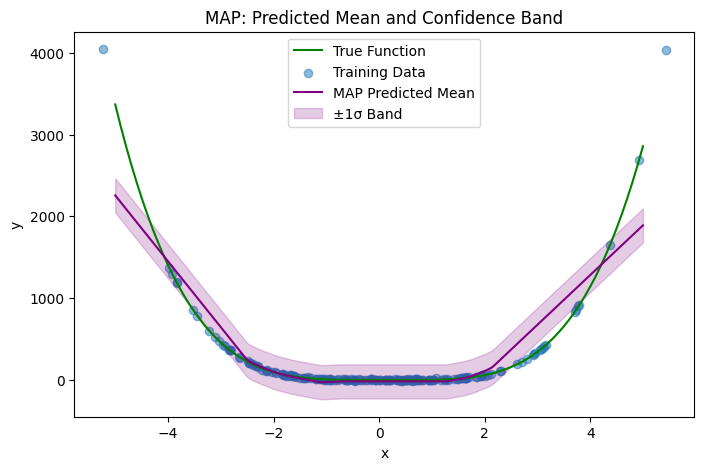

In [14]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.neural_network import MLPRegressor


# Set random seed for reproducibility
np.random.seed(42)

# i) Data Generation
# Coefficients
a0, a1, a2, a3, a4 = 0.5, -1.0, -0.5, -2.0, 5.0

# True function
def f(x):
    return a4*x**4 + a3*x**3 + a2*x**2 + a1*x + a0

# Data parameters
N = 200       # number of training samples
delta = 5.0   # noise standard deviation

# Generate inputs
x_train = np.random.normal(0, 2, N)
# Generate noisy observations
y_train = f(x_train) + np.random.normal(0, delta, N)

# Visualize
x_plot = np.linspace(-5, 5, 200)
plt.figure(figsize=(8,5))
plt.plot(x_plot, f(x_plot), label='True Function', color='green')
plt.scatter(x_train, y_train, label='Noisy Training Data', color='blue', alpha=0.5)
plt.xlabel('x')
plt.ylabel('y')
plt.title('True Function and Noisy Data')
plt.legend()
plt.show()

# ii) Gaussian Likelihood Model using NN
# Reshape inputs for sklearn
x_train_reshaped = x_train.reshape(-1,1)

# Define DNN architecture: 2 hidden layers with ReLU
dnn_mle = MLPRegressor(hidden_layer_sizes=(32,32), activation='relu',
                       solver='adam', max_iter=2000, random_state=42)

# Train the network (MLE)
dnn_mle.fit(x_train_reshaped, y_train)

# Predictions
y_pred = dnn_mle.predict(x_plot.reshape(-1,1))

# Plot
plt.figure(figsize=(8,5))
plt.plot(x_plot, f(x_plot), label='True Function', color='green')
plt.scatter(x_train, y_train, label='Noisy Training Data', alpha=0.5)
plt.plot(x_plot, y_pred, label='DNN Predicted Mean', color='red')
plt.xlabel('x')
plt.ylabel('y')
plt.title('MLE: Predicted Mean vs True Function')
plt.legend()
plt.show()

# iii) Confidence Band Viz
y_train_pred = dnn_mle.predict(x_train.reshape(-1,1))
residuals = y_train - y_train_pred
sigma_est = np.std(residuals)  # estimate of noise including model fit error

print(f"Estimated sigma from residuals: {sigma_est:.2f}")

plt.figure(figsize=(8,5))
plt.plot(x_plot, y_pred, label='Predicted Mean', color='red')
plt.fill_between(x_plot, y_pred - sigma_est, y_pred + sigma_est, color='red', alpha=0.2, label='±1σ Confidence Band')
plt.scatter(x_train, y_train, alpha=0.5, label='Training Data')
plt.plot(x_plot, f(x_plot), color='green', label='True Function')
plt.xlabel('x')
plt.ylabel('y')
plt.title('Confidence Band around Predicted Mean (MLE)')
plt.legend()
plt.show()

# iv) Probabilistic Coverage Test
# Generate test data
N_test = 50
x_test = np.random.normal(0, 2, N_test)
y_test = f(x_test) + np.random.normal(0, delta, N_test)
y_test_pred = dnn_mle.predict(x_test.reshape(-1,1))

# Count points within ±estimated sigma
within_band = np.sum((y_test >= y_test_pred - sigma_est) & (y_test <= y_test_pred + sigma_est))
coverage_percentage = within_band / N_test * 100
print(f"Percentage of test points within ±estimated sigma: {coverage_percentage:.2f}%")

# Plot test points
plt.figure(figsize=(8,5))
plt.plot(x_plot, y_pred, color='red', label='Predicted Mean')
plt.fill_between(x_plot, y_pred - sigma_est, y_pred + sigma_est, color='red', alpha=0.2, label='±1σ Band')
plt.scatter(x_test, y_test, color='blue', label='Test Data')
plt.xlabel('x')
plt.ylabel('y')
plt.title('Test Points vs Confidence Band (MLE)')
plt.legend()
plt.show()

# v) MAP Estimation
# MAP estimation with L2 regularization
dnn_map = MLPRegressor(hidden_layer_sizes=(32,32), activation='relu',
                       solver='adam', alpha=1e-3, max_iter=2000, random_state=42)

dnn_map.fit(x_train_reshaped, y_train)
y_map_pred = dnn_map.predict(x_plot.reshape(-1,1))

plt.figure(figsize=(8,5))
plt.plot(x_plot, f(x_plot), color='green', label='True Function')
plt.scatter(x_train, y_train, alpha=0.5, label='Training Data')
plt.plot(x_plot, y_map_pred, color='purple', label='MAP Predicted Mean')
plt.fill_between(x_plot, y_map_pred - sigma_est, y_map_pred + sigma_est, color='purple', alpha=.2, label='±1σ Band')
plt.xlabel('x')
plt.ylabel('y')
plt.title('MAP: Predicted Mean and Confidence Band')
plt.legend()
plt.show()

iii. The model captures the variability in the data. Since the variance is fixed, the band has constant width. Most the noisy points lie within the confidence band around the predicted mean which is expected for a Gaussian likelihood. 

iv. Out of the 50 newly generated test points, 84 percent lie within the +/- 1 standard deviation relecting the theoretical 68 percent and model error.

v. Adding L2 regularization smooths the predicted mean, making sure the network doesn't overfit noisy fluctuations in the training data. This gives a more stable prediction, especially in regions where training points are sparse. 

vi. MLE predictions can overfit the training noise, resulting in curves that deviate from the true function. MAP estimation with regularization produces smoother predictions that better approximate the underlying function. This improves generalization and keeps uncertainty bands consistent with the noise level.

## Q7 (10 Points) (Deep Neural Network Classification)

We revisit problem 6 from Homework 5. In this problem, you will use a **deep neural network (DNN)** to classify two types of iris flowers (*Iris Versicolour* and *Iris Virginica*) based on four features (petal length, petal width, sepal length, sepal width).

Instead of the linear model  
$$
z = \boldsymbol{\theta}^T \boldsymbol{x},
$$  
we now define  
$$
z = \mathrm{DNN}(\boldsymbol{x};\,\boldsymbol{\theta}),
$$  
where the DNN consists of multiple nonlinear layers and produces a **softmax** output representing class probabilities:

$$
P(y = k \mid \boldsymbol{x}, \boldsymbol{\theta}) =
\frac{\exp(z_k)}{\sum_j \exp(z_j)}.
$$

The model parameters $\boldsymbol{\theta}$ are optimized by minimizing the **cross-entropy loss**:
$$
\mathcal{L}(\boldsymbol{\theta}) = -\frac{1}{N}\sum_{i=1}^{N}\sum_{k=1}^{2}
y^{(i)}_k \log P(y^{(i)}_k \mid \boldsymbol{x}^{(i)}, \boldsymbol{\theta}).
$$

For this problem, use the dataset with \(N = 80\) training samples and \(20\) holdout (testing) samples, where  
- $y = 0$ -> *Iris Versicolour*  
- $y = 1$ -> *Iris Virginica*  

---

### (1)  
**Model architecture.**  
Define a DNN classifier using **`sklearn.neural_network.MLPClassifier`** with a softmax output layer (set `activation='relu'` and `solver='adam'`).  
Experiment with different depths and widths of hidden layers to achieve good classification performance.

---

### (2)  
**Training and evaluation (no regularization).**  
Train the DNN on the training data and evaluate accuracy on the testing data.  
Plot the classification results for the two flower classes, circling any misclassified points.  
Report the percentage of misclassifications.

---

### (3)  
**Regularization (L2 penalty).**  
Repeat part (2) but add L2 regularization by setting the `alpha` parameter to a nonzero value (e.g., `alpha = 0.01`).  
Plot the new classification results and report the misclassification percentage again.

---

### (4)  
**Comparison with Logistic Regression (Sklearn).**  
Using `sklearn.linear_model.LogisticRegression`, train and evaluate a logistic-regression classifier on the same data.  
Compare its accuracy and decision boundary with your DNN from parts (2) and (3).

---

### (5)  
**Analysis and discussion.**  
Discuss how the DNN results differ from logistic regression.  
Explain the effect of the nonlinear hidden layers and the role of regularization (`alpha`) in controlling model complexity and overfitting.

---

**Note:**  
If your network achieves perfect accuracy on the holdout data, that is acceptable.  
Focus your discussion on the relative behavior between the unregularized and regularized models, as well as the difference between DNN and logistic regression.


Accuracy (no regularization): 100.00%
Misclassification rate: 0.00%


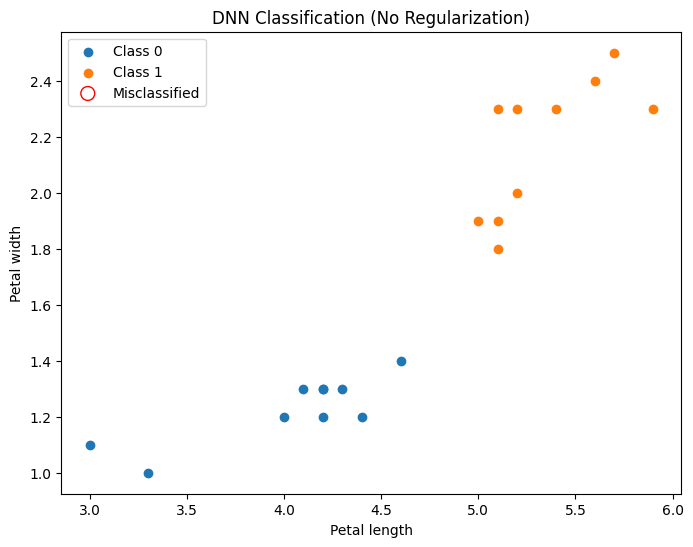

Accuracy (with L2 regularization): 100.00%
Misclassification rate: 0.00%


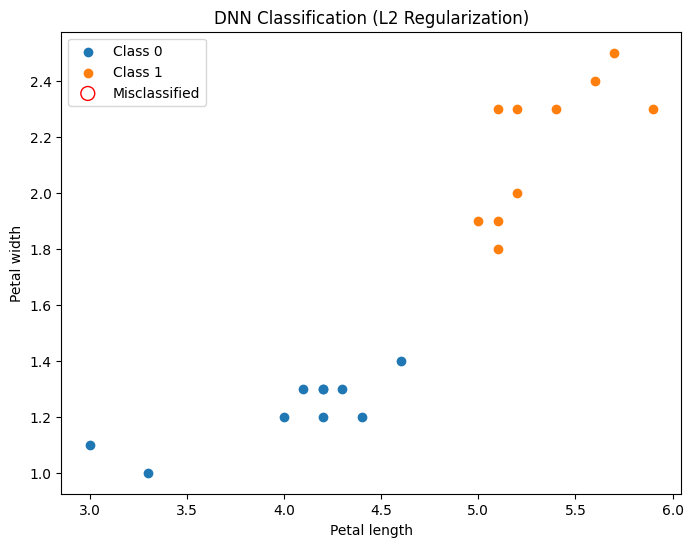

Logistic Regression Accuracy: 100.00%
Misclassification rate: 0.00%


In [18]:
from sklearn import datasets
import numpy as np
import matplotlib.pyplot as plt

# Load and visualize the Iris flower dataset
iris = datasets.load_iris()
# A copy of the target labels so we don't overwrite the original
y_all = iris.target.copy()
# Relabel: setosa is ignored, versicolor = 0, virginica = 1
y_all[50:100] = 0
y_all[100:150] = 1
# Training set: use a subset of versicolor and virginica
X = np.concatenate((iris.data[50:90], iris.data[100:140]), axis=0)
y = np.concatenate((y_all[50:90], y_all[100:140]), axis=0)

# Holdout set
X_holdout = np.concatenate((iris.data[90:100], iris.data[140:150]), axis=0)
y_holdout = np.concatenate((y_all[90:100], y_all[140:150]), axis=0)


# 1. Model Architecture
from sklearn.neural_network import MLPClassifier
dnn = MLPClassifier(hidden_layer_sizes=(10, 10), activation='relu',
                    solver='adam', max_iter=1000, random_state=42)

# 2. Training and Evaluation
dnn.fit(X, y)
y_pred = dnn.predict(X_holdout)
accuracy = np.mean(y_pred == y_holdout)
misclass_percent = 100 * (1 - accuracy)
print(f"Accuracy (no regularization): {accuracy*100:.2f}%")
print(f"Misclassification rate: {misclass_percent:.2f}%")
plt.figure(figsize=(8,6))
for i, cls in enumerate([0,1]):
    idx = (y_holdout == cls)
    plt.scatter(X_holdout[idx,2], X_holdout[idx,3], label=f'Class {cls}')
# Highlight misclassified points
mis_idx = (y_pred != y_holdout)
plt.scatter(X_holdout[mis_idx,2], X_holdout[mis_idx,3], 
            facecolors='none', edgecolors='r', s=100, label='Misclassified')

plt.xlabel('Petal length')
plt.ylabel('Petal width')
plt.title('DNN Classification (No Regularization)')
plt.legend()
plt.show()

# 3. L2 Regularization
dnn_reg = MLPClassifier(hidden_layer_sizes=(10, 5),
                        activation='relu',
                        solver='adam',
                        alpha=0.01,  # L2 penalty
                        max_iter=1000,
                        random_state=42)
dnn_reg.fit(X, y)
# Evaluate on holdout set
y_pred_reg = dnn_reg.predict(X_holdout)
accuracy_reg = np.mean(y_pred_reg == y_holdout)
misclass_percent_reg = 100 * (1 - accuracy_reg)
print(f"Accuracy (with L2 regularization): {accuracy_reg*100:.2f}%")
print(f"Misclassification rate: {misclass_percent_reg:.2f}%")
plt.figure(figsize=(8,6))
for i, cls in enumerate([0,1]):
    idx = (y_holdout == cls)
    plt.scatter(X_holdout[idx,2], X_holdout[idx,3], label=f'Class {cls}')

mis_idx = (y_pred_reg != y_holdout)
plt.scatter(X_holdout[mis_idx,2], X_holdout[mis_idx,3], 
            facecolors='none', edgecolors='r', s=100, label='Misclassified')

plt.xlabel('Petal length')
plt.ylabel('Petal width')
plt.title('DNN Classification (L2 Regularization)')
plt.legend()
plt.show()

# Compare with Logistic Regression
from sklearn.linear_model import LogisticRegression
logreg = LogisticRegression(solver='lbfgs')
logreg.fit(X, y)
y_pred_log = logreg.predict(X_holdout)
accuracy_log = np.mean(y_pred_log == y_holdout)
misclass_percent_log = 100 * (1 - accuracy_log)
print(f"Logistic Regression Accuracy: {accuracy_log*100:.2f}%")
print(f"Misclassification rate: {misclass_percent_log:.2f}%")

The main difference in the DNN results vs logistic regression results is the DNN can model nonlinear decision boundaries due to its hidden layers with ReLU activations. Logistic regression has linear boundaries so it can't separate classes if the boundary is curved. Adding layers increases model complexity allowing it to capture patterns deeply, therefore improving classification. Too deep or wide networks may overfit, which is where L2 regularization and alpha can penalize large weights, preventing such.